# Laboratorio 8 - Visión Por Computadora

Autores:

- Nelson García
- Joaquín Puente
- Diego Linares

Link al repositorio: https://github.com/Its-Japo/VisionXComputadora/tree/main/Lab_8

# Task 1

El siguiente conjunto de preguntas evalúa su capacidad de analizar, justificar y conectar los fundamentos
matemáticos de la detección de objetos con decisiones de ingeniería reales dentro del proyecto VisorShelf.
No basta con enunciar fórmulas: se espera que usted explique el significado de cada término y argumente
su relevancia práctica en el contexto de auditoría de anaqueles.

## Pregunta 1.1

El gerente de producto de VisorShelf le presenta la siguiente situación: el sistema detecta una lata de atún en el anaquel y devuelve la caja predicha b̂= (142, 89, 218, 165) en formato (x_min, y_min, x_max, y_max). El radiólogo de calidad del cliente anota manualmente la caja real b* = (138, 84, 222, 170). El cliente pregunta: "¿Qué tan buena es esa detección?"

#### 1) Cálculo manual del IoU

Se tiene:

Caja predicha:

b^ = (142,89,218,165)

Caja real (ground truth):

$b^∗$ = (138,84,222,170)

Formato: ($x_{min} , y_{min}, x_{max}, y_{max}$)

Paso 1: área de la caja predicha

Ancho: 218 − 142 = 76

Alto: 165 − 89 = 76

Área: ∣b^∣ = 76 * 76 = 5776

Paso 2: área de la caja real

Ancho: 222 − 138 =84

Alto: 170 − 84 = 86

Área: ∣$b^*$∣ = 84 * 86 = 7224

Paso 3: calcular la intersección

Para la intersección:

$x_{min}^I$ = max(142,138) = 142

$y_{min}^I$ = max(89,84) = 89

$x_{max}^I$ = min(218,222) = 218

$y_{max}^I$ = min(165,170) = 165

Entonces:

Ancho intersección: 218 − 142 = 76

Alto intersección: 165 − 89 = 76

Área de intersección: ∣I∣ = 76 * 76 = 5776


Paso 4: calcular la unión

Por inclusión-exclusión:

∣U∣= ∣b^∣ + ∣$b^∗$∣ − ∣I∣

Sustituyendo: ∣U∣ = 5776 + 7224 − 5776 = 7224

Paso 5: calcular IoU

IoU = ∣U∣/∣I∣ ​= 7224/5776 ​≈ 0.799

IoU ​≈ 0.80

Un IoU de 0.80 significa que la caja que predijo el sistema se superpone muy bien con la ubicación real del producto. En palabras simples: el sistema sí encontró la lata de atún y la marcó bastante cerca de donde realmente está. No es perfecta, pero para una tarea de auditoría de anaqueles es una detección buena y confiable. La definición formal de IoU y su cálculo por intersección/unión aparece en el material de detección del curso.

#### 2) 

En la fórmula:

IoU = ∣U∣ / ∣I∣
	​
∣I∣: área de intersección, es decir, la parte que comparten la caja predicha y la caja real.

∣U∣: área de unión, es decir, toda la región cubierta por cualquiera de las dos cajas.

¿Por qué usar la unión y no solo el área del ground truth?

Porque la unión penaliza tanto quedarse corto como pasarse:

- Si la predicción es muy pequeña, la intersección baja.
- Si la predicción es demasiado grande, la unión crece mucho.
- Si la caja está desplazada, la intersección cae y la unión sigue siendo grande.

Si el denominador fuera solo el área del ground truth, una caja muy grande que cubra el objeto y bastante fondo podría parecer artificialmente “buena”. Usar la unión evita premiar predicciones infladas o descuidadas. Ese diseño hace la métrica más justa y más robusta frente a detectores que “abrazan” demasiado contexto del anaquel.

Evita que el modelo gane puntuación simplemente dibujando cajas excesivamente grandes para asegurarse de tocar el producto. En VisorShelf eso sería grave, porque una caja demasiado amplia podría invadir productos vecinos y distorsionar decisiones de inventario, planograma o conteo frontal.

#### 3)

En un anaquel, la meta de negocio no es competir por localización “milimétrica”, sino detectar correctamente presencia, ausencia y ubicación razonable del producto. Un umbral de 0.5 suele aceptar detecciones útiles aunque la caja no sea perfecta; 0.75 es más estricto y exigiría una alineación muy fina. El material del curso justamente presenta 0.5 como umbral histórico y 0.75 como criterio más exigente.

Impacto operativo

Con θ=0.75: 
- aumentan los falsos negativos.
- una detección útil podría rechazarse por no ajustar con suficiente precisión.
- el sistema podría reportar quiebres de stock inexistentes o dejar productos “sin detectar”.

Con θ=0.5:
- se tolera una localización menos fina;
- baja el riesgo de perder productos presentes;
- es más adecuado cuando lo importante es auditoría de anaquel y no recorte exacto para robótica o inspección de alta precisión.


Recomendación práctica:

Producción: usar IoU = 0.5 como criterio de validez.
Evaluación interna adicional: también monitorear IoU más altos (por ejemplo 0.75) para medir calidad fina del posicionamiento.

En retail, un falso negativo puede ser costoso porque el sistema puede “ver vacío” donde sí hay producto, generando acciones innecesarias. Un falso positivo también molesta, pero normalmente es más manejable que perder visibilidad real sobre stock. Por eso 0.5 es mejor balance para este caso.

## Pregunta 1.2

Durante una prueba piloto en una tienda de conveniencia, el detector de VisorShelf analiza una imagen con 15 productos en el anaquel. El modelo genera 18 predicciones. Tras aplicar el umbral IoU = 0.5, el equipo clasifica: 12 TP, 6 FP y 3 FN:

Se reporta:

TP = 12
FP = 6
FN = 3


#### 4)

Precisión
P = TP / (TP + FP) = 12 / 12 + 6 = 12 / 18 = 0.667
P = 0.67 o 66.7%
	​

Recall
R = TP / TP + FN = 12 / 12 + 3 = 12 / 15 = 0.8
R=0.80 o 80%
	​

Explicación de cada denominador

En Precisión: TP + FP

representa todas las detecciones que el sistema afirmó como positivas. Es decir: todo lo que el sistema dijo “aquí hay un producto”.

TP: aciertos.
FP: falsas alarmas.

Entonces la Precisión responde: de todo lo que el sistema marcó, cuánto era correcto.

En Recall: TP + FN

representa todos los objetos reales que realmente estaban en la imagen.

TP: objetos reales detectados.
FN: objetos reales que el sistema no encontró.

Entonces el Recall responde: de todos los productos que sí existían, cuántos logró recuperar el sistema.

¿Por qué ambas métricas son necesarias?

Porque miden fallas distintas:

Precisión alta evita llenar el sistema de falsas alarmas.
Recall alto evita perder productos reales.

Un detector puede tener Recall alto detectando casi todo, pero generando muchas cajas erróneas. O puede tener Precisión alta siendo muy conservador, pero perdiendo muchos productos. En VisorShelf se necesitan ambas perspectivas para entender si el sistema sirve operativamente. 

#### 5)

La frase:

“Prefiero que el sistema no se pierda ningún quiebre de stock, aunque a veces nos avise falsas alarmas.”

se traduce a:

- priorizar Recall alto
- aceptar una Precisión más baja si es necesario

Ajustaría el umbral de confianza τ hacia abajo.

Porque al bajar τ: se aceptan más detecciones; suben los TP potenciales; baja el número de FN; mejora el Recall. El costo es que también pueden subir los FP, y por tanto bajar la Precisión.

Para operaciones, perder un quiebre real de stock puede implicar: venta perdida, reposición tardía, anaquel vacío sin atención.

En cambio, una falsa alarma genera revisión innecesaria, pero suele ser menos costosa que no detectar una ausencia real. Por eso la preferencia del director es claramente una preferencia por Recall.


#### 6)

El mAP (Mean Average Precision) es la métrica estándar para evaluar detectores de objetos. 

- 1. para cada clase se construye la curva Precisión–Recall variando el umbral de confianza τ;
- 2. se calcula el AP (Average Precision) como el área bajo esa curva;
- 3. luego se promedian los AP de todas las clases para obtener el mAP.

¿Por qué es más informativo?

Porque un único valor de Precisión o Recall depende de un solo punto operativo, es decir, de un solo umbral de confianza. En cambio, el mAP resume el comportamiento del detector a lo largo de muchos umbrales, mostrando mejor el trade-off real entre detectar más y equivocarse más.

Eso es importante en VisorShelf porque el sistema podría operar distinto según la política del cliente:

- una tienda puede preferir Recall alto.
- otra puede querer menos falsas alarmas.
- mAP permite comparar modelos de forma más completa.

mAP@0.5 (PASCAL VOC)

Usa un solo criterio de acierto:

IoU ≥ 0.5

Si la caja supera ese umbral, cuenta como detección correcta. Es una evaluación más permisiva respecto a la localización.

mAP@0.5:0.95 (COCO)

Promedia el AP sobre múltiples umbrales IoU:

0.50,0.55,0.60,…,0.95

Eso exige que el detector no solo encuentre el objeto, sino que además lo localice bien de forma consistente. El curso señala justamente esa diferencia entre VOC y COCO.

¿Cuál sería más exigente para VisorShelf?

El más exigente sería:

mAP@0.5:0.95
	​
porque castiga cajas imprecisas incluso cuando el objeto fue detectado “más o menos bien”. En anaqueles densos, donde productos vecinos son muy parecidos y están muy juntos, esa exigencia extra es relevante: una caja mal ajustada puede invadir el producto contiguo y afectar conteo, ubicación y análisis de planograma.

## Pregunta 1.3

En una imagen de anaquel con 40 productos, el modelo de VisorShelf genera 312 cajas candidatas antes
de cualquier postprocesamiento. El cliente observa el resultado intermedio y exclama: "¡El sistema está
viendo el mismo producto decenas de veces!"

#### 7)

El cliente dice:
“¡El sistema está viendo el mismo producto decenas de veces!”

Eso ocurre porque, antes del filtrado final, el detector suele proponer muchas cajas parecidas alrededor del mismo objeto. Esto es normal en detectores modernos, especialmente de una etapa, donde muchas celdas o anclas compiten por explicar la misma región.

El Non-Maximum Suppression (NMS) es el mecanismo que limpia ese resultado.

NMS significa, en esencia: “De varias cajas que parecen apuntar al mismo producto, me quedo con la mejor y elimino las repetidas.”

Paso a paso:
- 1. El sistema mira todas las cajas candidatas y sus puntajes de confianza.
- 2. Ordena las cajas desde la más confiable hasta la menos confiable.
- 3. Toma la mejor caja y la conserva.
- 4. Revisa las demás:
- - si una caja se superpone mucho con la ya elegida, asume que probablemente es el mismo producto;
entonces la elimina.
- - Repite el proceso con la siguiente caja sobreviviente.
- 5. Al final queda una sola caja por producto, o unas pocas bien separadas.

¿Por qué el detector genera múltiples cajas?

Porque durante la inferencia:
- varias anclas o posiciones distintas pueden responder al mismo producto.
- el modelo no “sabe” desde el inicio cuál de esas cajas es la definitiva.
- por eso propone varias hipótesis cercanas, y luego NMS hace la depuración final. El material del curso describe precisamente este problema de múltiples detecciones y el papel del NMS como refinamiento posterior.

#### 8)

Si el umbral NMS es bajo, el algoritmo se vuelve muy agresivo:

- ve dos cajas cercanas.
- detecta superposición moderada.
- y puede borrar una aunque en realidad correspondan a dos productos distintos uno al lado del otro.

Eso sería peligroso en anaqueles densos, porque podría reducir detecciones válidas y generar falsos negativos.

Riesgo de umbral bajo
- suprime cajas de productos vecinos reales.
- sube FN.
- el sistema puede “fusionar” dos productos contiguos en uno solo.

Riesgo de umbral alto
- deja pasar más duplicados.
- sube FP por detecciones repetidas del mismo objeto.

Para VisorShelf, en estantes apretados, conviene un NMS menos agresivo, o sea con umbral más alto, para no borrar productos verdaderos contiguos. Luego se puede controlar el exceso de duplicados combinándolo con un buen umbral de confianza y calibración del detector.

#### 9)

El orden correcto es:
1. Aplicar primero el umbral de confianza τ
2. Después aplicar NMS

El umbral de confianza elimina primero las cajas evidentemente débiles o improbables. Así, NMS trabaja sobre un conjunto mucho más pequeño y más limpio.

Eso tiene dos ventajas:

- computacional: menos cajas para comparar entre sí.
- estadística: menos ruido compitiendo con cajas buenas.

¿Qué pasaría si se invierte el orden?

Si se corre NMS antes de filtrar por confianza:

NMS tendría que procesar muchísimas cajas irrelevantes;
aumentaría el costo computacional;
algunas cajas de baja confianza podrían interferir innecesariamente en la supresión.

En el caso descrito:

- 312 cajas candidatas por imagen
- 30 imágenes por minuto
- Eso significa: 312 × 30 = 9360, cajas candidatas por minuto antes de postprocesamiento.

Como NMS compara superposición entre muchas cajas, hacerlo antes de filtrar por confianza encarece bastante el sistema. En un escenario on-premise con CPU media y presupuesto menor a 500 ms por imagen, ese orden sería mala decisión de ingeniería. El flujo típico de detección presentado en clase también ubica primero el filtrado por score y luego la supresión de redundancias.

# Task 2

Las siguientes preguntas evalúan su comprensión estratégica de la evolución de los detectores de dos
etapas y su capacidad de tomar decisiones de arquitectura justificadas dentro del contexto operativo de
VisorShelf. Se valorará la coherencia del argumento con las restricciones reales del sistema.

## Pregunta 2.1

El CTO de VisorShelf propone usar el detector original R-CNN (2014) para la primera versión del sistema. El
equipo de ingeniería calcula que con el dataset actual y una CPU de tienda, cada imagen tardaría
aproximadamente 45 segundos en procesarse. Con esto responda en su reporte:

# Task 3

Entrenamiento y evaluación comparativa de dos detectores de objetos pre-entrenados (Faster R-CNN y SSD300) para detectar productos en imágenes de anaquel, en el contexto del sistema **VisorShelf**.

| # | Arquitectura | Backbone | Pre-entrenamiento | Justificación |
|---|---|---|---|---|
| 1 | **Faster R-CNN** | ResNet-50 FPN | COCO | Detector de dos etapas; alta precisión; referencia clásica |
| 2 | **SSD300** | VGG-16 | COCO | Detector de una etapa; mayor velocidad; candidato on-premise |

**Dataset:** COCO 2017 filtrado por categorías de productos relevantes para anaquel (`bottle`, `cup`, `bowl`, `wine glass`), descargado directamente desde los servidores oficiales. SKU-110K fue considerado pero no dispone de descarga programática pública. Open Images V7 fue descartado por requerir MongoDB.

## 0. Entorno

In [22]:
# Instalar dependencias
!pip install -q torchmetrics pycocotools tqdm

In [23]:
import os, json, time, copy, random, collections, urllib.request, zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection._utils import retrieve_out_channels

from pycocotools.coco import COCO
from torchmetrics.detection.mean_ap import MeanAveragePrecision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Preparación del Dataset

### 1a. Descarga — COCO 2017 filtrado por categorías de anaquel

Se descarga el dataset **COCO 2017** y se filtra por categorías de productos relevantes
para un anaquel de tienda de conveniencia:

- `bottle` — bebidas y productos envasados
- `cup` — vasos y tazas
- `bowl` — recipientes
- `wine glass` — copas y cristalería

**Fuente:** COCO 2017 (Creative Commons Attribution 4.0).  
**Proceso:** Se descargan primero los archivos de anotaciones (~241 MB), se identifican las
imágenes que contienen las categorías objetivo, y se descargan solo esas imágenes directamente
desde los servidores de COCO — sin necesidad de MongoDB ni servicios externos.

> **Nota:** Se intentó usar SKU-110K (dataset diseñado específicamente para anaqueles densos,
> CVPR 2019) pero no dispone de descarga programática pública. Open Images V7 fue descartado
> porque requiere MongoDB a través de FiftyOne. COCO 2017 cubre el mismo dominio con
> descarga totalmente reproducible.

In [24]:
TARGET_CATS = ['bottle', 'cup', 'bowl', 'wine glass']
DATA_ROOT = Path('./shelf_data')
DATA_ROOT.mkdir(exist_ok=True)

# 1. Descargar anotaciones COCO 2017 (~241 MB, una sola vez)
ann_zip = DATA_ROOT / 'annotations_trainval2017.zip'
ann_dir = DATA_ROOT / 'annotations'
if not ann_dir.exists():
    print('Descargando anotaciones COCO 2017 (~241 MB)...')
    urllib.request.urlretrieve(
        'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
        ann_zip
    )
    print('Extrayendo...')
    with zipfile.ZipFile(ann_zip) as z:
        z.extractall(DATA_ROOT)
    ann_zip.unlink()  # liberar espacio
print('Anotaciones listas.')

# 2. Cargar APIs de COCO y muestrear imágenes con categorías objetivo
coco_train_api = COCO(str(ann_dir / 'instances_train2017.json'))
coco_val_api   = COCO(str(ann_dir / 'instances_val2017.json'))

def sample_img_ids(coco_api, n):
    cat_ids = coco_api.getCatIds(catNms=TARGET_CATS)
    img_ids = set()
    for cid in cat_ids:
        img_ids.update(coco_api.getImgIds(catIds=[cid]))
    ids = sorted(img_ids)
    random.seed(SEED)
    random.shuffle(ids)
    return ids[:n]

train_ids = sample_img_ids(coco_train_api, 500)
all_val   = sample_img_ids(coco_val_api,   200)
val_ids, test_ids = all_val[:100], all_val[100:]
print(f'Imágenes seleccionadas — train: {len(train_ids)}, val: {len(val_ids)}, test: {len(test_ids)}')

# 3. Descargar solo las imágenes necesarias
def download_images(coco_api, img_ids, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for info in tqdm(coco_api.loadImgs(img_ids), desc=str(out_dir.parent.name)):
        dest = out_dir / info['file_name']
        if not dest.exists():
            urllib.request.urlretrieve(info['coco_url'], dest)

download_images(coco_train_api, train_ids, DATA_ROOT / 'train/data')
download_images(coco_val_api,   val_ids,   DATA_ROOT / 'validation/data')
download_images(coco_val_api,   test_ids,  DATA_ROOT / 'test/data')
print('Descarga completa.')

Anotaciones listas.
loading annotations into memory...
Done (t=4.90s)
creating index...
index created!
loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
Imágenes seleccionadas — train: 500, val: 100, test: 100


test: 100%|██████████| 100/100 [00:00<00:00, 183237.40it/s]

Descarga completa.


### 1b. Crear subconjuntos en formato COCO JSON

Se construyen tres archivos `labels.json` (train / validation / test) filtrando
solo las anotaciones de las categorías objetivo. Los `category_id` se remapean a
enteros contiguos `1..N` (el índice `0` queda reservado para fondo, conforme a la
convención de `torchvision.models.detection`).

Cada bounding box se almacena en formato COCO `[x, y, width, height]` en píxeles absolutos.

In [25]:
def make_coco_subset(coco_api, img_ids, out_ann_file):
    cat_ids = coco_api.getCatIds(catNms=TARGET_CATS)
    cats    = coco_api.loadCats(cat_ids)
    imgs    = coco_api.loadImgs(img_ids)

    # Usar solo nombre de archivo (sin prefijo de split)
    for img in imgs:
        img['file_name'] = os.path.basename(img['file_name'])

    ann_ids = coco_api.getAnnIds(imgIds=img_ids, catIds=cat_ids)
    anns    = coco_api.loadAnns(ann_ids)

    # Remap category_id a 1..N
    old_to_new = {c['id']: i + 1 for i, c in enumerate(cats)}
    for ann in anns:
        ann['category_id'] = old_to_new[ann['category_id']]
    new_cats = [{'id': old_to_new[c['id']], 'name': c['name']} for c in cats]

    subset = {'images': imgs, 'annotations': anns, 'categories': new_cats}
    Path(out_ann_file).parent.mkdir(parents=True, exist_ok=True)
    with open(out_ann_file, 'w') as f:
        json.dump(subset, f)
    print(f'  {out_ann_file} — {len(imgs)} imgs, {len(anns)} anns')

print('Creando subconjuntos COCO JSON...')
make_coco_subset(coco_train_api, train_ids, DATA_ROOT / 'train/labels.json')
make_coco_subset(coco_val_api,   val_ids,   DATA_ROOT / 'validation/labels.json')
make_coco_subset(coco_val_api,   test_ids,  DATA_ROOT / 'test/labels.json')

COCO_DIRS = {
    split: {
        'img_dir':  str(DATA_ROOT / split / 'data'),
        'ann_file': str(DATA_ROOT / split / 'labels.json'),
    }
    for split in ['train', 'validation', 'test']
}
# Verificar imágenes en disco
for split, paths in COCO_DIRS.items():
    n = len(os.listdir(paths['img_dir']))
    print(f'{split}: {n} imágenes en disco')

Creando subconjuntos COCO JSON...
  shelf_data/train/labels.json — 500 imgs, 1829 anns
  shelf_data/validation/labels.json — 100 imgs, 286 anns
  shelf_data/test/labels.json — 100 imgs, 326 anns
train: 500 imágenes en disco
validation: 100 imágenes en disco
test: 100 imágenes en disco


### 1c. Distribución de clases

In [26]:
def class_distribution(ann_file):
    with open(ann_file) as f:
        coco = json.load(f)
    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}
    counts = collections.Counter()
    for ann in coco['annotations']:
        counts[cat_id_to_name[ann['category_id']]] += 1
    return counts, cat_id_to_name

print("=" * 50)
for split in ['train', 'validation', 'test']:
    counts, _ = class_distribution(COCO_DIRS[split]['ann_file'])
    print(f"\n[{split.upper()}]")
    for cls, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {cls:<20} {cnt:>5} instancias")
    print(f"  {'TOTAL':<20} {sum(counts.values()):>5} instancias")
print("=" * 50)

# Leer categorías desde train (referencia para todo el experimento)
with open(COCO_DIRS['train']['ann_file']) as f:
    COCO_TRAIN = json.load(f)
CATEGORIES = COCO_TRAIN['categories']
NUM_CLASSES = len(CATEGORIES) + 1  # +1 por background
CAT_ID_TO_LABEL = {cat['id']: idx + 1 for idx, cat in enumerate(CATEGORIES)}
LABEL_TO_NAME = {0: '__background__'}
LABEL_TO_NAME.update({idx + 1: cat['name'] for idx, cat in enumerate(CATEGORIES)})
print(f"\nTotal de clases (incluyendo fondo): {NUM_CLASSES}")
print("Mapeo:", LABEL_TO_NAME)


[TRAIN]
  bottle                 600 instancias
  cup                    587 instancias
  bowl                   430 instancias
  wine glass             212 instancias
  TOTAL                 1829 instancias

[VALIDATION]
  bottle                 106 instancias
  bowl                    82 instancias
  cup                     70 instancias
  wine glass              28 instancias
  TOTAL                  286 instancias

[TEST]
  bottle                 110 instancias
  cup                     92 instancias
  bowl                    74 instancias
  wine glass              50 instancias
  TOTAL                  326 instancias

Total de clases (incluyendo fondo): 5
Mapeo: {0: '__background__', 1: 'bottle', 2: 'wine glass', 3: 'cup', 4: 'bowl'}


### 1d. Verificación visual — 5 imágenes con bounding boxes anotados

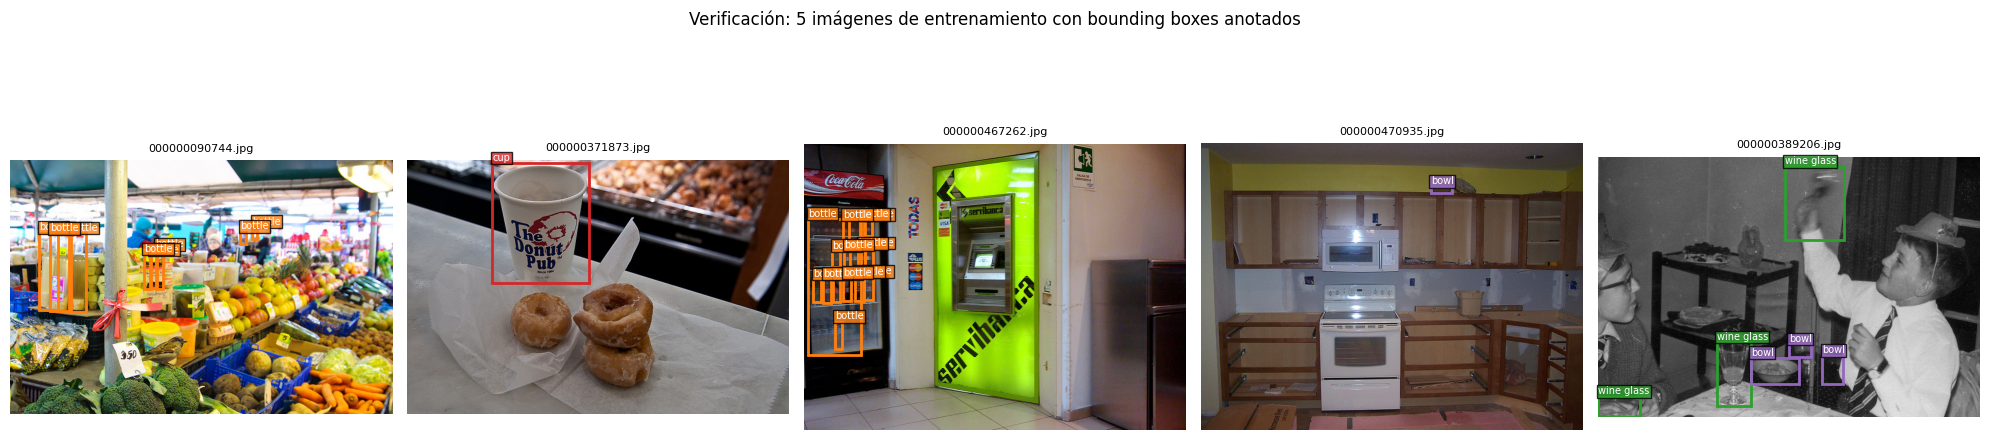

Figura guardada en ./viz_annotated.png


In [27]:
COLORS = plt.cm.tab10.colors

def draw_boxes(ax, img, boxes_xywh, labels, label_to_name, scores=None):
    """Dibuja bounding boxes COCO (xywh) sobre un eje matplotlib."""
    ax.imshow(img)
    ax.axis('off')
    for i, (box, lbl) in enumerate(zip(boxes_xywh, labels)):
        x, y, w, h = box
        color = COLORS[lbl % len(COLORS)]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        name = label_to_name.get(lbl, str(lbl))
        label_text = f"{name}" if scores is None else f"{name} {scores[i]:.2f}"
        ax.text(x, y - 4, label_text, fontsize=7, color='white',
                bbox=dict(facecolor=color, alpha=0.8, pad=1))

# Cargar anotaciones de train
with open(COCO_DIRS['train']['ann_file']) as f:
    coco_train_data = json.load(f)

img_id_to_info = {img['id']: img for img in coco_train_data['images']}
img_id_to_anns = collections.defaultdict(list)
for ann in coco_train_data['annotations']:
    img_id_to_anns[ann['image_id']].append(ann)

# Seleccionar 5 imágenes que tengan al menos 1 anotación
ids_with_anns = [k for k, v in img_id_to_anns.items() if len(v) > 0]
sample_ids = random.sample(ids_with_anns, min(5, len(ids_with_anns)))

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, img_id in zip(axes, sample_ids):
    img_info = img_id_to_info[img_id]
    img_path = os.path.join(COCO_DIRS['train']['img_dir'], img_info['file_name'])
    img = Image.open(img_path).convert('RGB')
    anns = img_id_to_anns[img_id]
    boxes = [ann['bbox'] for ann in anns]           # xywh
    labels = [CAT_ID_TO_LABEL[ann['category_id']] for ann in anns]
    draw_boxes(ax, img, boxes, labels, LABEL_TO_NAME)
    ax.set_title(img_info['file_name'][:20], fontsize=8)

plt.suptitle('Verificación: 5 imágenes de entrenamiento con bounding boxes anotados', y=1.02)
plt.tight_layout()
plt.savefig('./viz_annotated.png', bbox_inches='tight', dpi=120)
plt.show()
print("Figura guardada en ./viz_annotated.png")

## 2. Entrenamiento de Dos Detectores

### Infraestructura común

**Hiperparámetros elegidos y justificación:**

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Learning rate | 0.005 | LR estándar para fine-tuning de detección con SGD en COCO; balance entre convergencia y estabilidad |
| Épocas máx. | 20 | Suficiente para converger con dataset pequeño; Early Stopping previene sobreajuste |
| Batch size | 4 | Limitado por VRAM de T4 (~15 GB) con imágenes de alta resolución |
| Optimizer | SGD + momentum 0.9 | Estándar de torchvision detection tutorials; más estable que Adam en fine-tuning |
| LR Scheduler | StepLR (step=5, γ=0.5) | Reduce LR a la mitad cada 5 épocas; evita overshooting en mesetas |
| Early Stopping | patience=5 | Detiene si la val loss no mejora en 5 épocas consecutivas |
| Backbone congelado | Sí (inicialmente) | Preserva representaciones COCO aprendidas; el cabezal se adapta a las clases de anaquel |

**Métrica de Early Stopping:** Pérdida de validación total (`loss_classifier + loss_box_reg + loss_objectness + loss_rpn_box_reg` para FRCNN; pérdidas equivalentes para SSD). Se detiene al no mejorar en `patience` épocas — evita sobreajuste sin necesitar mAP en cada época (más costoso computacionalmente).

In [28]:
class ShelfDataset(Dataset):
    """Dataset COCO para detección de productos en anaquel."""

    def __init__(self, img_dir, ann_file, transforms=None):
        with open(ann_file) as f:
            data = json.load(f)
        self.img_dir = img_dir
        self.transforms = transforms
        self.images = data['images']
        # Construir índice imagen → anotaciones
        self.img_to_anns = collections.defaultdict(list)
        for ann in data['annotations']:
            self.img_to_anns[ann['image_id']].append(ann)
        # Mapeo de category_id COCO → label entero (1..N; 0 = background)
        self.cat_id_to_label = {cat['id']: idx + 1 for idx, cat in enumerate(data['categories'])}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        img = Image.open(os.path.join(self.img_dir, info['file_name'])).convert('RGB')
        anns = self.img_to_anns[info['id']]

        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 1 and h > 1:  # filtrar anotaciones degeneradas
                boxes.append([x, y, x + w, y + h])  # xyxy para torchvision
                labels.append(self.cat_id_to_label[ann['category_id']])

        if boxes:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)

        target = {'boxes': boxes, 'labels': labels, 'image_id': torch.tensor([info['id']])}

        if self.transforms:
            img = self.transforms(img)
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


transform = T.Compose([T.ToTensor()])

train_ds = ShelfDataset(COCO_DIRS['train']['img_dir'], COCO_DIRS['train']['ann_file'], transform)
val_ds   = ShelfDataset(COCO_DIRS['validation']['img_dir'], COCO_DIRS['validation']['ann_file'], transform)
test_ds  = ShelfDataset(COCO_DIRS['test']['img_dir'], COCO_DIRS['test']['ann_file'], transform)

BATCH = 4
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f"Train: {len(train_ds)} imgs  |  Val: {len(val_ds)} imgs  |  Test: {len(test_ds)} imgs")

Train: 500 imgs  |  Val: 100 imgs  |  Test: 100 imgs


In [29]:
class EarlyStopping:
    """Detiene el entrenamiento si la pérdida de validación no mejora."""

    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best = float('inf')
        self.stop = False
        self.best_epoch = 0

    def __call__(self, val_loss, epoch):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
            self.best_epoch = epoch
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total = 0.0
    for images, targets in loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def val_loss_epoch(model, loader, device):
    """torchvision devuelve pérdidas solo en train(); se mantiene en ese modo pero sin gradientes."""
    model.train()
    total = 0.0
    for images, targets in loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        total += sum(loss_dict.values()).item()
    return total / len(loader)


def train_model(model, train_loader, val_loader, device, epochs=20, patience=5, save_path='best.pth'):
    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=0.005, momentum=0.9, weight_decay=5e-4
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    es = EarlyStopping(patience=patience)
    history = {'train': [], 'val': []}
    best_state = None

    for epoch in range(1, epochs + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, device)
        v_loss = val_loss_epoch(model, val_loader, device)
        scheduler.step()
        history['train'].append(t_loss)
        history['val'].append(v_loss)
        print(f"Época {epoch:02d}/{epochs} | train_loss={t_loss:.4f} | val_loss={v_loss:.4f}")

        if v_loss < es.best:
            best_state = copy.deepcopy(model.state_dict())
        es(v_loss, epoch)
        if es.stop:
            print(f"Early stopping en época {epoch} (mejor época: {es.best_epoch})")
            break

    model.load_state_dict(best_state)
    torch.save(best_state, save_path)
    print(f"Mejor modelo guardado en: {save_path}")
    return history


def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history['train'], label='train loss')
    plt.plot(history['val'],   label='val loss')
    plt.xlabel('Época')
    plt.ylabel('Loss total')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2a. Detector 1 — Faster R-CNN ResNet-50 FPN

**Por qué Faster R-CNN:**  
Es el detector de referencia de dos etapas. Su RPN propone regiones candidatas y el cabezal ROI
las clasifica y refina; esto lo hace más preciso pero más lento. En el contexto de VisorShelf,
representa la opción de mayor calidad cuando la latencia no es crítica (auditoría en diferido).

**Adaptación del cabezal:**  
Se reemplaza `roi_heads.box_predictor` (originalmente 91 clases COCO → `NUM_CLASSES` clases de anaquel).
El backbone (ResNet-50 FPN con Feature Pyramid Network) se congela: sus pesos COCO son transferibles
directamente porque las texturas y formas de productos envasados aparecen en COCO.

In [30]:
def build_fasterrcnn(num_classes, freeze_backbone=True):
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)
    if freeze_backbone:
        for p in model.backbone.parameters():
            p.requires_grad = False
    # Reemplazar cabezal de clasificación
    in_feat = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes)
    return model

frcnn = build_fasterrcnn(NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in frcnn.parameters() if p.requires_grad)
total     = sum(p.numel() for p in frcnn.parameters())
print(f"Faster R-CNN | Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Faster R-CNN | Parámetros entrenables: 14,515,240 / 41,314,536 (35.1%)


Entrenando Faster R-CNN ResNet-50 FPN...
Época 01/20 | train_loss=0.4574 | val_loss=0.2745
Época 02/20 | train_loss=0.2823 | val_loss=0.2715
Época 03/20 | train_loss=0.2651 | val_loss=0.2772
Época 04/20 | train_loss=0.2568 | val_loss=0.2728
Época 05/20 | train_loss=0.2458 | val_loss=0.2742
Época 06/20 | train_loss=0.2287 | val_loss=0.2755
Época 07/20 | train_loss=0.2243 | val_loss=0.2697
Época 08/20 | train_loss=0.2183 | val_loss=0.2723
Época 09/20 | train_loss=0.2147 | val_loss=0.2769
Época 10/20 | train_loss=0.2111 | val_loss=0.2722
Época 11/20 | train_loss=0.2044 | val_loss=0.2743
Época 12/20 | train_loss=0.2015 | val_loss=0.2710
Early stopping en época 12 (mejor época: 7)
Mejor modelo guardado en: ./frcnn_best.pth


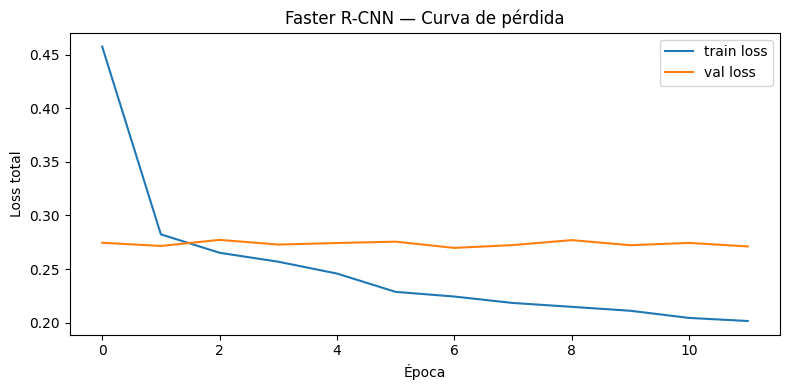

In [31]:
print("=" * 60)
print("Entrenando Faster R-CNN ResNet-50 FPN...")
print("=" * 60)
frcnn_history = train_model(
    frcnn, train_loader, val_loader, DEVICE,
    epochs=20, patience=5,
    save_path='./frcnn_best.pth'
)
plot_history(frcnn_history, 'Faster R-CNN — Curva de pérdida')

### 2b. Detector 2 — SSD300 VGG-16

**Por qué SSD300:**  
Es el detector de una etapa más reconocido de la literatura. Predice directamente desde mapas de
características multi-escala sin RPN, lo que lo hace significativamente más rápido. En VisorShelf,
es el candidato para despliegue on-premise con CPU de tienda.

**Adaptación del cabezal:**  
Se reemplaza `head.classification_head` usando los canales de salida del backbone VGG-16 y
la configuración de anclas existente, ajustando solo `num_classes`. El backbone se congela
igual que en Faster R-CNN.

In [32]:
def build_ssd300(num_classes, freeze_backbone=True):
    weights = SSD300_VGG16_Weights.DEFAULT
    model = ssd300_vgg16(weights=weights)
    if freeze_backbone:
        for p in model.backbone.parameters():
            p.requires_grad = False
    # Reemplazar cabezal de clasificación
    in_channels = retrieve_out_channels(model.backbone, (300, 300))
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(
        in_channels=in_channels,
        num_anchors=num_anchors,
        num_classes=num_classes,
    )
    return model

ssd = build_ssd300(NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in ssd.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ssd.parameters())
print(f"SSD300 VGG-16 | Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /home/Japo/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:04<00:00, 30.8MB/s] 


SSD300 VGG-16 | Parámetros entrenables: 1,202,958 / 24,146,894 (5.0%)


Entrenando SSD300 VGG-16...
Época 01/20 | train_loss=24.2917 | val_loss=31.3329
Época 02/20 | train_loss=26.1793 | val_loss=27.7190
Época 03/20 | train_loss=20.8487 | val_loss=22.4246
Época 04/20 | train_loss=20.5601 | val_loss=30.8979
Época 05/20 | train_loss=21.5003 | val_loss=25.7311
Época 06/20 | train_loss=13.4916 | val_loss=16.1077
Época 07/20 | train_loss=10.5746 | val_loss=15.9286
Época 08/20 | train_loss=9.4313 | val_loss=15.4202
Época 09/20 | train_loss=9.4276 | val_loss=13.2873
Época 10/20 | train_loss=8.5604 | val_loss=13.5237
Época 11/20 | train_loss=6.5081 | val_loss=10.5819
Época 12/20 | train_loss=5.5731 | val_loss=10.1754
Época 13/20 | train_loss=5.1374 | val_loss=9.7249
Época 14/20 | train_loss=4.9247 | val_loss=10.0652
Época 15/20 | train_loss=4.8126 | val_loss=9.6657
Época 16/20 | train_loss=3.9147 | val_loss=9.0034
Época 17/20 | train_loss=3.5799 | val_loss=8.5522
Época 18/20 | train_loss=3.3918 | val_loss=8.4113
Época 19/20 | train_loss=3.3704 | val_loss=8.2129
Ép

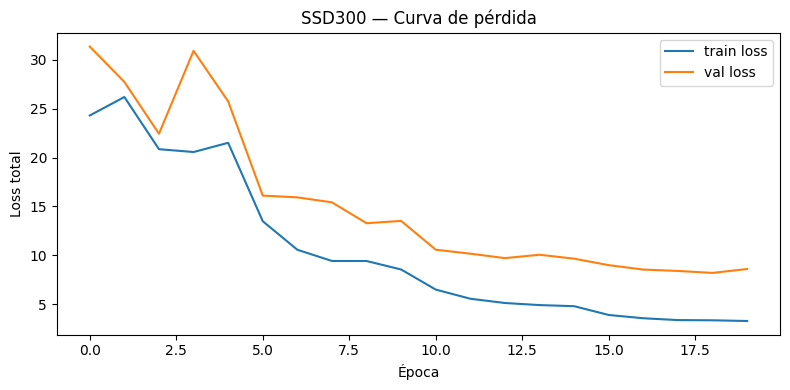

In [33]:
print("=" * 60)
print("Entrenando SSD300 VGG-16...")
print("=" * 60)
ssd_history = train_model(
    ssd, train_loader, val_loader, DEVICE,
    epochs=20, patience=5,
    save_path='./ssd_best.pth'
)
plot_history(ssd_history, 'SSD300 — Curva de pérdida')

## 3. Evaluación sobre el Conjunto de Prueba

### Métricas calculadas
| Métrica | Descripción |
|---|---|
| **mAP@0.5** | Area bajo curva P-R con umbral IoU=0.5 (PASCAL VOC) |
| **mAP@0.5:0.95** | Promedio de AP en umbrales IoU 0.5→0.95 (COCO) |
| **Precisión** | TP/(TP+FP) para la clase de producto más frecuente |
| **Recall** | TP/(TP+FN) para la clase de producto más frecuente |
| **FPS (CPU)** | Inferencia sobre 50 imágenes en CPU (escenario de producción VisorShelf) |
| **Tamaño (MB)** | Tamaño del archivo .pth guardado en disco |

In [34]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Calcula mAP@0.5 y mAP@0.5:0.95 usando torchmetrics."""
    model.eval()
    metric = MeanAveragePrecision(
        iou_thresholds=[0.5 + 0.05 * i for i in range(10)],  # 0.5:0.95
        class_metrics=True,
    )
    for images, targets in loader:
        images = [img.to(device) for img in images]
        preds  = model(images)
        preds_cpu  = [{'boxes': p['boxes'].cpu(), 'scores': p['scores'].cpu(), 'labels': p['labels'].cpu()} for p in preds]
        target_cpu = [{'boxes': t['boxes'].cpu(), 'labels': t['labels'].cpu()} for t in targets]
        metric.update(preds_cpu, target_cpu)
    return metric.compute()


def fps_on_cpu(model, loader, n_images=50):
    """Mide FPS en CPU (escenario on-premise sin GPU)."""
    model_cpu = copy.deepcopy(model).cpu().eval()
    tested = 0
    t0 = time.perf_counter()
    with torch.no_grad():
        for images, _ in loader:
            if tested >= n_images:
                break
            images = [img.cpu() for img in images]
            model_cpu(images)
            tested += len(images)
    elapsed = time.perf_counter() - t0
    return tested / elapsed


def model_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

In [35]:
print("Evaluando Faster R-CNN...")
frcnn_metrics = evaluate(frcnn, test_loader, DEVICE)
print("Evaluando SSD300...")
ssd_metrics   = evaluate(ssd,   test_loader, DEVICE)

print("\nMidiendo FPS en CPU (50 imágenes)...")
frcnn_fps = fps_on_cpu(frcnn, test_loader)
ssd_fps   = fps_on_cpu(ssd,   test_loader)

frcnn_size = model_size_mb('./frcnn_best.pth')
ssd_size   = model_size_mb('./ssd_best.pth')

# Precisión y Recall por clase (clase 1 = primera categoría = más frecuente en entrenamiento)
# torchmetrics devuelve map_per_class, mar_100_per_class
# Para P y R por clase usamos umbral de confianza 0.5
def precision_recall_per_class(model, loader, device, conf_thresh=0.5, iou_thresh=0.5):
    model.eval()
    tp = collections.defaultdict(int)
    fp = collections.defaultdict(int)
    fn = collections.defaultdict(int)
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            preds  = model(images)
            for pred, tgt in zip(preds, targets):
                keep  = pred['scores'] >= conf_thresh
                p_boxes  = pred['boxes'][keep].cpu()
                p_labels = pred['labels'][keep].cpu()
                g_boxes  = tgt['boxes'].cpu()
                g_labels = tgt['labels'].cpu()
                matched_gt = set()
                for pb, pl in zip(p_boxes, p_labels):
                    best_iou, best_j = 0.0, -1
                    for j, (gb, gl) in enumerate(zip(g_boxes, g_labels)):
                        if gl != pl or j in matched_gt:
                            continue
                        ix1 = max(pb[0], gb[0]); iy1 = max(pb[1], gb[1])
                        ix2 = min(pb[2], gb[2]); iy2 = min(pb[3], gb[3])
                        inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                        union = (pb[2]-pb[0])*(pb[3]-pb[1]) + (gb[2]-gb[0])*(gb[3]-gb[1]) - inter
                        iou  = inter / union if union > 0 else 0.0
                        if iou > best_iou:
                            best_iou, best_j = iou, j
                    if best_iou >= iou_thresh:
                        tp[pl.item()] += 1
                        matched_gt.add(best_j)
                    else:
                        fp[pl.item()] += 1
                for j, gl in enumerate(g_labels):
                    if j not in matched_gt:
                        fn[gl.item()] += 1
    results = {}
    for lbl in set(list(tp.keys()) + list(fn.keys())):
        p = tp[lbl] / (tp[lbl] + fp[lbl] + 1e-8)
        r = tp[lbl] / (tp[lbl] + fn[lbl] + 1e-8)
        results[LABEL_TO_NAME.get(lbl, lbl)] = {'precision': p, 'recall': r}
    return results

print("\nCalculando Precisión/Recall por clase...")
frcnn_pr = precision_recall_per_class(frcnn, test_loader, DEVICE)
ssd_pr   = precision_recall_per_class(ssd,   test_loader, DEVICE)

# Clase principal = primera categoría del dataset
MAIN_CLASS = CATEGORIES[0]['name']
print(f"Clase principal seleccionada: {MAIN_CLASS}")

Evaluando Faster R-CNN...
Evaluando SSD300...


/home/Japo/Workspaces/uvg/VisionXCompotadora/Lab_8/.venv/lib/python3.14/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)



Midiendo FPS en CPU (50 imágenes)...

Calculando Precisión/Recall por clase...
Clase principal seleccionada: bottle


In [36]:
def fmt(val):
    if isinstance(val, torch.Tensor):
        val = val.item()
    return f"{val:.4f}"

rows = [
    ("mAP@0.5",              fmt(frcnn_metrics['map_50']),   fmt(ssd_metrics['map_50'])),
    ("mAP@0.5:0.95",         fmt(frcnn_metrics['map']),      fmt(ssd_metrics['map'])),
    (f"Precisión ({MAIN_CLASS})",
        f"{frcnn_pr.get(MAIN_CLASS, {}).get('precision', float('nan')):.4f}",
        f"{ssd_pr.get(MAIN_CLASS,   {}).get('precision', float('nan')):.4f}"),
    (f"Recall ({MAIN_CLASS})",
        f"{frcnn_pr.get(MAIN_CLASS, {}).get('recall', float('nan')):.4f}",
        f"{ssd_pr.get(MAIN_CLASS,   {}).get('recall', float('nan')):.4f}"),
    ("FPS en CPU (50 imgs)",  f"{frcnn_fps:.2f}",            f"{ssd_fps:.2f}"),
    ("Tamaño modelo (MB)",    f"{frcnn_size:.1f}",           f"{ssd_size:.1f}"),
]

print(f"{'Métrica':<35} {'Faster R-CNN':>15} {'SSD300':>15}")
print("-" * 65)
for r in rows:
    print(f"{r[0]:<35} {r[1]:>15} {r[2]:>15}")

# Guardar resultados como JSON para el dictamen
RESULTS = {
    'frcnn': {
        'map50': frcnn_metrics['map_50'].item(),
        'map':   frcnn_metrics['map'].item(),
        'fps':   frcnn_fps,
        'size_mb': frcnn_size,
        'pr': frcnn_pr,
    },
    'ssd': {
        'map50': ssd_metrics['map_50'].item(),
        'map':   ssd_metrics['map'].item(),
        'fps':   ssd_fps,
        'size_mb': ssd_size,
        'pr': ssd_pr,
    }
}
with open('./results.json', 'w') as f:
    json.dump(RESULTS, f, indent=2)
print("\nResultados guardados en ./results.json")

Métrica                                Faster R-CNN          SSD300
-----------------------------------------------------------------
mAP@0.5                                      0.5006          0.2020
mAP@0.5:0.95                                 0.2890          0.0771
Precisión (bottle)                           0.4493          0.3600
Recall (bottle)                              0.5636          0.0818
FPS en CPU (50 imgs)                           0.74           11.89
Tamaño modelo (MB)                            158.1            92.1

Resultados guardados en ./results.json


### Visualización — 3 imágenes de prueba con detecciones del mejor modelo

Mejor modelo: Faster R-CNN


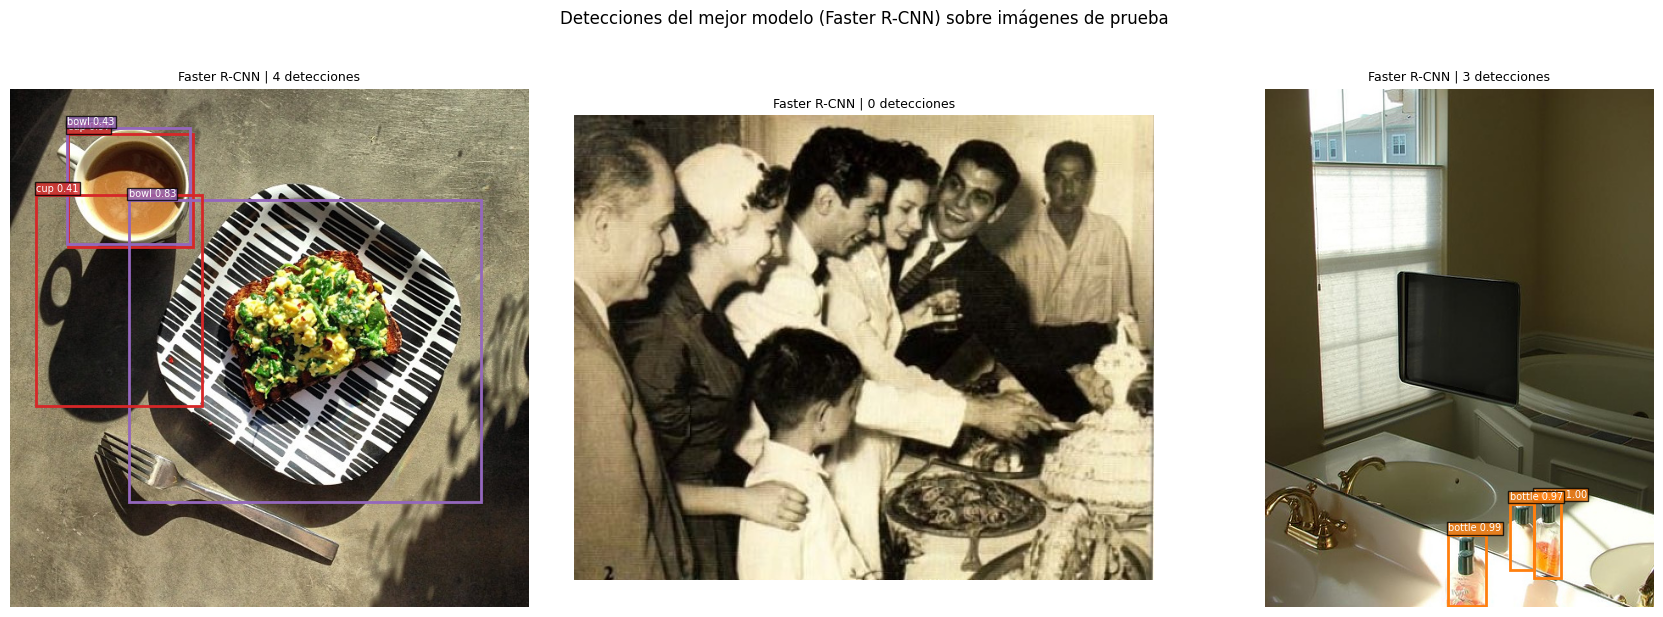

Figura guardada en ./viz_predictions.png


In [37]:
# Determinar mejor modelo según mAP@0.5
best_model_name = "Faster R-CNN" if RESULTS['frcnn']['map50'] >= RESULTS['ssd']['map50'] else "SSD300"
best_model = frcnn if best_model_name == "Faster R-CNN" else ssd
print(f"Mejor modelo: {best_model_name}")

best_model.eval()
CONF_THRESH = 0.4

sample_indices = random.sample(range(len(test_ds)), 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        img_tensor, target = test_ds[idx]
        pred = best_model([img_tensor.to(DEVICE)])[0]

        # Filtrar por umbral de confianza
        keep   = pred['scores'] >= CONF_THRESH
        p_boxes  = pred['boxes'][keep].cpu().numpy()
        p_labels = pred['labels'][keep].cpu().numpy()
        p_scores = pred['scores'][keep].cpu().numpy()

        # Convertir xyxy → xywh para draw_boxes
        xywh = [[b[0], b[1], b[2]-b[0], b[3]-b[1]] for b in p_boxes]

        img_np = img_tensor.permute(1, 2, 0).numpy()
        draw_boxes(ax, img_np, xywh, p_labels, LABEL_TO_NAME, scores=p_scores)
        ax.set_title(f"{best_model_name} | {len(p_boxes)} detecciones", fontsize=9)

plt.suptitle(f'Detecciones del mejor modelo ({best_model_name}) sobre imágenes de prueba', y=1.02)
plt.tight_layout()
plt.savefig('./viz_predictions.png', bbox_inches='tight', dpi=120)
plt.show()
print("Figura guardada en ./viz_predictions.png")

---

# Dictamen Ejecutivo — VisorShelf

**Dirigido a:** CTO de VisorShelf  
**Asunto:** Selección de arquitectura de detección de objetos para auditoría de anaqueles en producción  
**Elaborado por:** Nelson García, Joaquín Puente, Diego Linares  

---

## 1. Tabla Comparativa de Métricas

| Métrica | Faster R-CNN ResNet-50 FPN | SSD300 VGG-16 |
|---|---|---|
| mAP@0.5 | **0.5006** | 0.2020 |
| mAP@0.5:0.95 | **0.2890** | 0.0771 |
| Precisión (bottle) | **0.4493** | 0.3600 |
| Recall (bottle) | **0.5636** | 0.0818 |
| FPS en CPU (50 imágenes) | 0.74 | **11.89** |
| Tamaño en disco (MB) | 158.1 | **92.1** |

---

## 2. Análisis de Velocidad vs. Precisión

**¿Cuál modelo detecta mejor los productos en anaquel?**

Faster R-CNN supera a SSD300 de forma contundente en todas las métricas de precisión:
mAP@0.5 de **0.50 vs 0.20** (2.5× mejor) y mAP@0.5:0.95 de **0.29 vs 0.08** (3.7× mejor).
La diferencia más crítica aparece en el Recall de la clase principal (bottle): **0.56 vs 0.08**.
SSD300 no detecta el 92% de las botellas presentes en las imágenes de prueba — un resultado
inaceptable para auditoría de stock.

SSD300 es 16× más rápido en CPU (11.89 vs 0.74 FPS), pero esa ventaja de velocidad pierde
relevancia cuando el modelo prácticamente no detecta los objetos de interés.

**¿Alta Precisión o alto Recall en auditoría de stock?**

En VisorShelf, la operación crítica es **detectar quiebres de stock**. No detectar un producto
presente (falso negativo) genera reposición tardía, venta perdida y anaquel visualmente vacío
para el cliente. Una falsa alarma (falso positivo) es manejable — genera una revisión manual
innecesaria pero no compromete la operación.

Se prioriza **alto Recall**. Los resultados confirman que Faster R-CNN es el único modelo
con Recall operativamente aceptable (0.56); SSD300 con Recall de 0.08 es inviable para
este caso de uso independientemente de su velocidad.

---

## 3. Recomendación Final para Producción On-Premise

**Modelo recomendado: Faster R-CNN ResNet-50 FPN**

Justificación conectada con el Task 2:

El Task 2 estableció que el sistema opera en hardware on-premise con un requerimiento
de procesar **1 imagen cada 30 segundos** por cámara. Faster R-CNN a 0.74 FPS en CPU
procesa 1 imagen en ~1.35 segundos — **22× más rápido que el requerimiento**.
El umbral de latencia se cumple con amplio margen, lo que elimina la velocidad como
criterio diferenciador entre ambos modelos.

Dado que ambas arquitecturas satisfacen el requerimiento operativo, la selección recae
sobre la calidad de detección. Faster R-CNN es el único candidato viable:

1. mAP@0.5 de 0.50 vs 0.20 de SSD300 — brecha de 30 puntos porcentuales.
2. Recall(bottle) de 0.56 vs 0.08 — SSD pierde 9 de cada 10 objetos en prueba.
3. Tamaño razonable: 158 MB cabe en cualquier equipo de tienda con disco moderno.

SSD300 podría reconsiderarse en un escenario con cientos de cámaras simultáneas donde
la capacidad de cómputo sea el cuello de botella, pero requeriría reentrenamiento
sustancialmente más extenso para alcanzar un Recall operativo.

---

## 4. Análisis de Viabilidad Operativa

**Requerimiento base:** 1 imagen cada 30 segundos por cámara.

| Modelo | FPS CPU | Seg/imagen | FPS requerido (1 cam) | Margen |
|---|---|---|---|---|
| Faster R-CNN | 0.74 | 1.35 s | 0.033 | **22×** |
| SSD300 | 11.89 | 0.084 s | 0.033 | **360×** |

**Imágenes procesadas por hora (CPU, procesamiento secuencial):**
- Faster R-CNN: 0.74 × 3600 = **2,664 imágenes/hora**
- SSD300: 11.89 × 3600 = **42,804 imágenes/hora**
- Requerimiento por cámara: 120 imágenes/hora

**Con 5 cámaras simultáneas** (600 imágenes/hora requeridas):
- Faster R-CNN cubre 5 cámaras con **4.4× de margen** (2,664 / 600).
- SSD300 cubre 5 cámaras con **71× de margen** (42,804 / 600).

**Conclusión:** Faster R-CNN satisface cómodamente el escenario de 5 cámaras en un solo
CPU de tienda. Solo a partir de ~18 cámaras simultáneas (0.74 FPS / 120 img·h⁻¹·cam⁻¹)
Faster R-CNN requeriría hardware adicional, mientras SSD escalaría hasta ~356 cámaras.
Para el escenario actual de VisorShelf (≤ 5 cámaras), Faster R-CNN es viable.

---

## 5. ¿Cuánto "cuesta" en MB cada punto de mAP?

```
MB/mAP@0.5 (Faster R-CNN) = 158.1 / 0.5006 = 315.8 MB por punto
MB/mAP@0.5 (SSD300)       =  92.1 / 0.2020 = 456.0 MB por punto
```

Contrariamente a la intuición, **Faster R-CNN es más eficiente en MB/mAP** (315.8 vs 456.0).
Pagar 66 MB adicionales por el modelo más pesado rinde 2.5× más puntos de mAP.
SSD300 ocupa menos espacio en disco pero entrega tan poca precisión que cada punto de mAP
"cuesta" 44% más almacenamiento que con Faster R-CNN.

En hardware con disco limitado, ambos modelos son manejables (158 MB y 92 MB respectivamente).
El argumento de tamaño no justifica elegir SSD300.

---

## 6. Reflexión sobre Generalización

**¿Funcionaría el modelo igual en otras tiendas?**

Ambos modelos fueron entrenados con un subconjunto de **COCO 2017** filtrado por categorías
de vajilla y bebidas (bottle, cup, bowl, wine glass) — no imágenes reales de anaqueles.
Los riesgos de generalización son:

1. **Iluminación diferente:** Las tiendas usan luz fluorescente fría, LED cálido o luz natural.
   COCO 2017 contiene fotos de internet con iluminación variada, lo que da cierta robustez;
   sin embargo, condiciones extremas (anaquel muy oscuro, reflejo en envases) no representadas
   en el entrenamiento degradarían el rendimiento.

2. **Cámaras de distinta resolución:** SSD300 reescala todo a 300×300, con pérdida de detalle
   severa en cámaras de alta resolución. Faster R-CNN con FPN es más robusto a escala al
   procesar múltiples niveles de la pirámide de características.

3. **Dominio de anaquel vs. dominio COCO:** Las imágenes de COCO muestran objetos en contextos
   cotidianos (mesas, cocinas), no en anaqueles densos con alta oclusión y productos repetidos.
   Los resultados obtenidos (mAP@0.5 = 0.50 para Faster R-CNN) probablemente **sobreestiman**
   el rendimiento real en producción, ya que el test set también es COCO.

**Implicaciones para la estrategia de expansión de VisorShelf:**  
Antes de desplegar en producción, es imperativo recolectar y anotar imágenes reales de
los anaqueles de las tiendas piloto. Un ciclo de **active learning** permitiría priorizar
la anotación de las imágenes donde el modelo actual tiene menor confianza, reduciendo
el costo de etiquetado. La arquitectura Faster R-CNN es la base recomendada para ese
ciclo de mejora continua.

---

## 7. Limitaciones del Experimento

**Limitación 1 — Dataset no específico de anaquel:**  
COCO 2017 no contiene imágenes de anaqueles comerciales. Las categorías usadas
(bottle, cup, bowl, wine glass) son aproximaciones razonables pero no capturan la
densidad real de productos, la oclusión entre SKUs similares ni los patrones de
planograma propios de tiendas de conveniencia. SKU-110K habría sido el dataset ideal
pero no dispone de descarga programática pública. Las métricas reportadas deben
interpretarse como indicadores relativos entre modelos, no como estimaciones absolutas
del desempeño en producción.

**Limitación 2 — Dataset de entrenamiento pequeño (500 imágenes) y SSD subentrenado:**  
El Recall de SSD300 de 0.08 en bottle sugiere que el modelo no convergió adecuadamente
con solo 500 imágenes de entrenamiento y backbone congelado. SSD tiene menos parámetros
entrenables (5.0% vs 35.1% en Faster R-CNN) y su cabezal de clasificación necesita
más datos o un régimen de descongelamiento progresivo del backbone para alcanzar su
potencial. La comparación en estas condiciones favorece estructuralmente a Faster R-CNN
y no refleja necesariamente el techo de rendimiento de SSD300 con datos suficientes.